# Objetivo A — Métricas Custom para Reducción de Falsos Positivos
## Convenio PLUS TI – Universidad del Valle 2025

**Estructura del notebook:**
1. Setup y carga de datos
2. Selección de features y split temporal
3. **Modelo base** — AUC-ROC / F1 (baseline)
4. **Paso 4** — Objetivo general: reducir FP ratio con recall ≥ 90%
   - `feval_fp_ratio`: penalización directa de FP
   - `feval_balanced`: balance entre recall y FP ratio
5. **Paso 6** — Objetivo del grupo: maximizar monto salvado
   - `feval_amount_recall_floor`: monto salvado + piso de recall 90%
   - `feval_amount_fp_weighted`: monto salvado penalizado por FP ratio
   - `feval_amount_precision_recall`: F-beta ponderado por monto
6. Comparativa final de todos los modelos

## 0. Setup e imports

In [18]:
import os
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    confusion_matrix, roc_auc_score,
    f1_score, precision_recall_curve
)

SEED = 22
np.random.seed(SEED)
print('LightGBM version:', lgb.__version__)

LightGBM version: 4.6.0


## 0.1 Configuración GPU

In [19]:
import subprocess

def check_gpu():
    try:
        result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
        if result.returncode == 0:
            print('✓ GPU detectada')
            for line in result.stdout.split('\n'):
                if any(x in line for x in ['Tesla','T4','A100','V100','RTX','GTX']):
                    print(' ', line.strip())
            return True
        print('✗ No se detectó GPU'); return False
    except FileNotFoundError:
        print('✗ nvidia-smi no encontrado'); return False

GPU_AVAILABLE = check_gpu()
GPU_PARAMS = {'device': 'gpu', 'gpu_platform_id': 0, 'gpu_device_id': 0} if GPU_AVAILABLE else {}
print('\nGPU_PARAMS:', GPU_PARAMS if GPU_PARAMS else 'CPU mode')

✓ GPU detectada
  |   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |

GPU_PARAMS: {'device': 'gpu', 'gpu_platform_id': 0, 'gpu_device_id': 0}


## 1. Carga del dataset

In [20]:
from google.colab import drive
drive.mount('/content/drive')

PATH_DATASETS = '/content/drive/MyDrive/proyecto_plus_ti/datasets/'
PATH_PROJECT  = '/content/drive/MyDrive/proyecto_plus_ti/'
PATH_OUTPUTS  = PATH_PROJECT + 'models/modelo_a'
os.makedirs(PATH_OUTPUTS, exist_ok=True)

FILE = 'bo_vip_clean.csv'
print(f'PATH: {PATH_DATASETS}')

df = pd.read_csv(PATH_DATASETS + FILE, parse_dates=['datetime_tx'])
print(f'Shape: {df.shape}')
print(f'Fraude: {df["is_fraud"].mean():.2%}')
df.head(3)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PATH: /content/drive/MyDrive/proyecto_plus_ti/datasets/
Shape: (100003, 50)
Fraude: 4.92%


,datetime_tx,bank_code,bank_name,bank_country,bank_tier,client_segment,channel,card_brand,MTI,DE3_processing_code,...,approved,response_description,client_baseline_amount,client_home_city,is_fraud,month,time_since_last_txn_min,txn_count_last_1h,txn_count_last_24h,amount_zscore_customer
0,2025-01-13 16:00:42,BO-VIP,BO-VIP,BO,vip,PRIVATE,ECOM,VISA,100,0,...,True,Approved,1945.42,TARIJA,0,1,-1.000000,0,0,-0.749960
1,2025-01-18 15:50:53,BO-VIP,BO-VIP,BO,vip,UNKNOWN,ATM,VISA,100,10000,...,True,Approved,1945.42,TARIJA,0,1,7190.183333,0,0,-0.628929
2,2025-01-23 12:12:56,BO-VIP,BO-VIP,BO,vip,PRIVATE,POS,VISA,100,0,...,True,Approved,1945.42,TARIJA,0,1,6982.050000,0,0,0.919492


## 2. Selección de features

In [21]:
# Columnas excluidas: leakage, IDs, target, auxiliares de tiempo
EXCLUDE = [
    'is_fraud',
    'datetime_tx',
    'month',
    'DE43_card_acceptor_name_location',  # texto libre, alta cardinalidad
    'client_home_city',                  # alta cardinalidad
    'approved',                          # leakage
    'response_description',              # leakage (derivado de response_code)
]

CAT_COLS = [
    'bank_code', 'bank_name', 'bank_country', 'bank_tier',
    'client_segment', 'channel', 'card_brand',
    'day_of_week', 'currency_tx_alpha',
    'DE52_pin_data_present', 'DE55_emv_data_present',
    'DE60_pos_terminal_type', 'DE63_network_specific',
    'DE123_pos_data_code',
]

df_model = df.copy()
label_encoders = {}
for col in CAT_COLS:
    if col in df_model.columns:
        le = LabelEncoder()
        df_model[col] = le.fit_transform(df_model[col].astype(str))
        label_encoders[col] = le

FEATURES = [c for c in df_model.columns if c not in EXCLUDE]
TARGET   = 'is_fraud'

print(f'Total features: {len(FEATURES)}')
print(FEATURES)

Total features: 43
['bank_code', 'bank_name', 'bank_country', 'bank_tier', 'client_segment', 'channel', 'card_brand', 'MTI', 'DE3_processing_code', 'DE4_amount_transaction', 'DE6_amount_cardholder_billing', 'DE9_conversion_rate_billing', 'DE18_merchant_category_code', 'DE19_acquirer_country_code', 'DE22_pos_entry_mode', 'DE23_card_seq_number', 'DE25_pos_condition_code', 'DE32_acquiring_institution_id', 'DE39_response_code', 'DE49_currency_code_transaction', 'DE50_currency_code_settlement', 'DE51_currency_code_billing', 'DE52_pin_data_present', 'DE55_emv_data_present', 'DE58_authorizing_agent_id', 'DE60_pos_terminal_type', 'DE61_pos_extended_data', 'DE63_network_specific', 'DE100_receiving_institution_id', 'DE123_pos_data_code', 'amount_local', 'amount_tx_currency', 'currency_tx_alpha', 'amount_usd', 'is_international', 'distance_from_home_km', 'hour_local', 'day_of_week', 'client_baseline_amount', 'time_since_last_txn_min', 'txn_count_last_1h', 'txn_count_last_24h', 'amount_zscore_cust

## 3. Split temporal — último trimestre como test

El dataset cubre enero–junio (2 trimestres).  
- **Train:** trimestre 1 → meses 1, 2, 3  
- **Test:** trimestre 2 → meses 4, 5, 6  

Adicionalmente se reporta junio por separado para cumplir con la instrucción de la sección 1 del enunciado.

In [22]:
train_mask = df_model['month'].isin([1, 2, 3])
test_mask  = df_model['month'].isin([4, 5, 6])
june_mask  = df_model['month'] == 6

X_train = df_model.loc[train_mask, FEATURES]
y_train = df_model.loc[train_mask, TARGET]

X_test  = df_model.loc[test_mask, FEATURES]
y_test  = df_model.loc[test_mask, TARGET]

X_june  = df_model.loc[june_mask, FEATURES]
y_june  = df_model.loc[june_mask, TARGET]

# Montos para la métrica de monto salvado
amounts_test = df.loc[test_mask, 'amount_usd'].values
amounts_june = df.loc[june_mask, 'amount_usd'].values

print(f'Train (ene-mar): {X_train.shape} | fraude: {y_train.mean():.2%}')
print(f'Test  (abr-jun): {X_test.shape}  | fraude: {y_test.mean():.2%}')
print(f'Junio solo:      {X_june.shape}  | fraude: {y_june.mean():.2%}')

Train (ene-mar): (50027, 43) | fraude: 5.06%
Test  (abr-jun): (49882, 43)  | fraude: 4.79%
Junio solo:      (16073, 43)  | fraude: 4.52%


## 4. Ajuste por desbalance de clases

Con ~5% de fraudes usamos `scale_pos_weight = n_neg / n_pos`.  
Sin embargo, para no hacer el modelo demasiado agresivo (lo que produce FP ratio alto),
usamos una fracción del peso total: **0.5 × (n_neg / n_pos)**. Esto reduce el sesgo
hacia alarmar todo, manteniendo sensibilidad razonable.

In [23]:
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos_weight_full = n_neg / n_pos
scale_pos_weight      = scale_pos_weight_full * 0.5  # moderado para reducir FP

print(f'Negativos : {n_neg:,}')
print(f'Positivos : {n_pos:,}')
print(f'SPW full  : {scale_pos_weight_full:.2f}')
print(f'SPW usado : {scale_pos_weight:.2f}  (moderado para controlar FP)')

Negativos : 47,498
Positivos : 2,529
SPW full  : 18.78
SPW usado : 9.39  (moderado para controlar FP)


## 5. Parámetros base y datasets LightGBM

In [24]:
BASE_PARAMS = {
    'objective':         'binary',
    'metric':            'auc',
    'scale_pos_weight':  scale_pos_weight,
    'learning_rate':     0.05,
    'num_leaves':        63,
    'max_depth':         -1,
    'min_child_samples': 50,      # menos sobreajuste, menos FP
    'feature_fraction':  0.8,
    'bagging_fraction':  0.8,
    'bagging_freq':      5,
    'reg_alpha':         0.5,
    'reg_lambda':        5.0,     # regularización más fuerte para controlar FP
    'verbose':          -1,
    'seed':              SEED,
    'n_jobs':           -1,
    **GPU_PARAMS,
}

dtrain = lgb.Dataset(X_train, label=y_train)
dval   = lgb.Dataset(X_test,  label=y_test, reference=dtrain)

CALLBACKS = lambda: [
    lgb.early_stopping(stopping_rounds=50, verbose=False),
    lgb.log_evaluation(period=100),
]

print('Datasets y parámetros listos.')

Datasets y parámetros listos.


## 6. Funciones auxiliares de evaluación

In [25]:
def find_threshold_for_recall(y_true, y_prob, min_recall=0.90):
    """
    Retorna el threshold más alto que garantiza recall >= min_recall.
    Mayor threshold = menos FP, pero más FN. Buscamos el máximo que aún cumple el piso.
    """
    _, recalls, thresholds = precision_recall_curve(y_true, y_prob)
    best_t = thresholds[0]
    for r, t in zip(recalls[:-1], thresholds):
        if r >= min_recall:
            best_t = t
    return best_t


def evaluate_model(model, X_test, y_test, amounts_test, model_name, min_recall=0.90):
    """Evalúa el modelo al threshold óptimo para recall >= min_recall."""
    y_prob = model.predict(X_test, num_iteration=model.best_iteration)
    threshold = find_threshold_for_recall(y_test, y_prob, min_recall)
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    recall    = tp / (tp + fn)   if (tp + fn) > 0 else 0
    precision = tp / (tp + fp)   if (tp + fp) > 0 else 0
    fp_ratio  = fp / (tp + fp)   if (tp + fp) > 0 else 1.0
    f1        = f1_score(y_test, y_pred)
    auc_roc   = roc_auc_score(y_test, y_prob)

    tp_mask          = (y_pred == 1) & (np.array(y_test) == 1)
    total_fraud_amt  = amounts_test[np.array(y_test) == 1].sum()
    amount_saved     = amounts_test[tp_mask].sum()
    pct_amount_saved = amount_saved / total_fraud_amt if total_fraud_amt > 0 else 0

    results = {
        'Modelo':             model_name,
        'Threshold':          round(threshold, 4),
        'AUC-ROC':            round(auc_roc, 4),
        'Recall':             round(recall, 4),
        'Precision':          round(precision, 4),
        'F1-Score':           round(f1, 4),
        'FP Ratio':           round(fp_ratio, 4),
        'TP':                 int(tp),
        'FP':                 int(fp),
        'FN':                 int(fn),
        'TN':                 int(tn),
        'Monto Fraude Total': round(total_fraud_amt, 2),
        'Monto Salvado':      round(amount_saved, 2),
        '% Monto Salvado':    round(pct_amount_saved * 100, 2),
    }

    print(f'\n{"="*60}')
    print(f'  {model_name}')
    print(f'{"="*60}')
    for k, v in results.items():
        print(f'  {k:<25} {v}')

    return results, y_prob, y_pred, threshold


all_results = []  # acumula resultados de todos los modelos
print('Funciones auxiliares listas.')

Funciones auxiliares listas.


---
# MODELO BASE
Entrenamiento con métricas tradicionales AUC-ROC y F1. Sin feval personalizada.  
Sirve como baseline para medir el impacto de cada función custom.

In [26]:
print('=== MODELO BASE — AUC-ROC / F1 ===')

model_base = lgb.train(
    params          = BASE_PARAMS,
    train_set       = dtrain,
    num_boost_round = 500,
    valid_sets      = [dval],
    valid_names     = ['val'],
    callbacks       = CALLBACKS(),
)

res_base, prob_base, pred_base, thr_base = evaluate_model(
    model_base, X_test, y_test, amounts_test, 'Modelo Base — AUC/F1'
)
all_results.append(res_base)
model_base.save_model(f'{PATH_OUTPUTS}/model_base.lgb')

=== MODELO BASE — AUC-ROC / F1 ===
[100]	val's auc: 0.901476

  Modelo Base — AUC/F1
  Modelo                    Modelo Base — AUC/F1
  Threshold                 0.061
  AUC-ROC                   0.9024
  Recall                    0.9004
  Precision                 0.0887
  F1-Score                  0.1616
  FP Ratio                  0.9113
  TP                        2151
  FP                        22088
  FN                        238
  TN                        25405
  Monto Fraude Total        2652157.24
  Monto Salvado             2555924.73
  % Monto Salvado           96.37


---
# PASO 4 — Objetivo general: reducir FP ratio

Estas dos funciones atacan el problema general del banco: demasiadas alertas falsas.

## feval_fp_ratio
Minimiza directamente `FP / (TP + FP)`.  
El modelo aprende a ser más cuidadoso antes de lanzar una alerta.

In [27]:
def feval_fp_ratio(preds, train_data):
    """
    Penalización directa de falsos positivos.
    ratio_fp = FP / (TP + FP)  →  minimizar.

    Retorna: (nombre, valor, is_higher_better)
    """
    labels = train_data.get_label().astype(int)
    threshold = np.percentile(preds, 95)  # top 5% más probable = fraude
    binary = (preds >= threshold).astype(int)

    TP = np.sum((binary == 1) & (labels == 1))
    FP = np.sum((binary == 1) & (labels == 0))

    denom = TP + FP
    ratio = FP / denom if denom > 0 else 1.0

    return 'fp_ratio', ratio, False  # False = menor es mejor


print('=== PASO 4 — Modelo 1: feval_fp_ratio ===')

model_fp = lgb.train(
    params          = BASE_PARAMS,
    train_set       = dtrain,
    num_boost_round = 500,
    valid_sets      = [dval],
    valid_names     = ['val'],
    feval           = feval_fp_ratio,
    callbacks       = CALLBACKS(),
)

res_fp, prob_fp, pred_fp, thr_fp = evaluate_model(
    model_fp, X_test, y_test, amounts_test, 'P4-M1 — FP Ratio'
)
all_results.append(res_fp)
model_fp.save_model(f'{PATH_OUTPUTS}/model_fp_ratio.lgb')

=== PASO 4 — Modelo 1: feval_fp_ratio ===
[100]	val's auc: 0.90185	val's fp_ratio: 0.248497

  P4-M1 — FP Ratio
  Modelo                    P4-M1 — FP Ratio
  Threshold                 0.0566
  AUC-ROC                   0.9024
  Recall                    0.9004
  Precision                 0.0858
  F1-Score                  0.1567
  FP Ratio                  0.9142
  TP                        2151
  FP                        22909
  FN                        238
  TN                        24584
  Monto Fraude Total        2652157.24
  Monto Salvado             2553812.22
  % Monto Salvado           96.29


## feval_balanced
Combina recall y FP ratio en un único score: `recall - α × fp_ratio`  
con `α = 0.5`, que penaliza FP sin sacrificar demasiado la detección.  
Maximizar este score fuerza al modelo a buscar el balance entre ambos objetivos.

In [28]:
def feval_balanced(preds, train_data, alpha=0.5):
    """
    Métrica balanceada: recall - alpha * fp_ratio
    alpha=0.5 penaliza los FP a la mitad del peso del recall.
    Maximizar.
    """
    labels = train_data.get_label().astype(int)
    threshold = np.percentile(preds, 95)  # top 5% más probable = fraude
    binary = (preds >= threshold).astype(int)

    TP = np.sum((binary == 1) & (labels == 1))
    FP = np.sum((binary == 1) & (labels == 0))
    FN = np.sum((binary == 0) & (labels == 1))

    recall   = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    fp_ratio = FP / (TP + FP) if (TP + FP) > 0 else 1.0

    score = recall - alpha * fp_ratio

    return 'balanced_score', score, True  # True = mayor es mejor


print('=== PASO 4 — Modelo 2: feval_balanced ===')

model_bal = lgb.train(
    params          = BASE_PARAMS,
    train_set       = dtrain,
    num_boost_round = 500,
    valid_sets      = [dval],
    valid_names     = ['val'],
    feval           = feval_balanced,
    callbacks       = CALLBACKS(),
)

res_bal, prob_bal, pred_bal, thr_bal = evaluate_model(
    model_bal, X_test, y_test, amounts_test, 'P4-M2 — Balanced'
)
all_results.append(res_bal)
model_bal.save_model(f'{PATH_OUTPUTS}/model_balanced.lgb')

=== PASO 4 — Modelo 2: feval_balanced ===
[100]	val's auc: 0.901503	val's balanced_score: 0.662456

  P4-M2 — Balanced
  Modelo                    P4-M2 — Balanced
  Threshold                 0.0655
  AUC-ROC                   0.9023
  Recall                    0.9004
  Precision                 0.0856
  F1-Score                  0.1564
  FP Ratio                  0.9144
  TP                        2151
  FP                        22972
  FN                        238
  TN                        24521
  Monto Fraude Total        2652157.24
  Monto Salvado             2555984.75
  % Monto Salvado           96.37


---
# PASO 6 — Objetivo del grupo: Maximizar monto salvado

Las 3 funciones siguientes están alineadas con el objetivo específico del grupo.
Todas priorizan detectar el mayor valor económico en fraudes, con distintas estrategias
para manejar el trade-off con los falsos positivos.

## feval_amount_recall_floor
Maximiza la fracción del monto de fraude detectado.  
Si el recall cae bajo 90%, penaliza cuadráticamente el score.  
Garantiza cobertura mínima antes de optimizar por monto.

In [29]:
def make_feval_amount_recall_floor(amounts, recall_floor=0.90, penalty_factor=2.0):
    """
    score = monto_TP / monto_total_fraudes
    Si recall < recall_floor:
        score *= (recall / recall_floor) ** penalty_factor
    Maximizar.
    """
    amounts = np.array(amounts)

    def _feval(preds, train_data):
        labels = train_data.get_label().astype(int)
        threshold = np.percentile(preds, 95)  # top 5% más probable = fraude
        binary = (preds >= threshold).astype(int)

        TP = np.sum((binary == 1) & (labels == 1))
        FN = np.sum((binary == 0) & (labels == 1))
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0

        tp_mask        = (binary == 1) & (labels == 1)
        total_fraud    = amounts[labels == 1].sum()
        amount_saved   = amounts[tp_mask].sum()
        score_base     = amount_saved / total_fraud if total_fraud > 0 else 0.0

        if recall < recall_floor:
            score = score_base * (recall / recall_floor) ** penalty_factor
        else:
            score = score_base

        return 'amount_recall_floor', score, True

    return _feval


print('=== PASO 6 — Modelo 3: feval_amount_recall_floor ===')

model_arf = lgb.train(
    params          = BASE_PARAMS,
    train_set       = dtrain,
    num_boost_round = 500,
    valid_sets      = [dval],
    valid_names     = ['val'],
    feval           = make_feval_amount_recall_floor(amounts_test),
    callbacks       = CALLBACKS(),
)

res_arf, prob_arf, pred_arf, thr_arf = evaluate_model(
    model_arf, X_test, y_test, amounts_test, 'P6-M3 — Amount + Recall Floor'
)
all_results.append(res_arf)
model_arf.save_model(f'{PATH_OUTPUTS}/model_amount_recall_floor.lgb')

=== PASO 6 — Modelo 3: feval_amount_recall_floor ===
[100]	val's auc: 0.901479	val's amount_recall_floor: 0.702155

  P6-M3 — Amount + Recall Floor
  Modelo                    P6-M3 — Amount + Recall Floor
  Threshold                 0.061
  AUC-ROC                   0.9024
  Recall                    0.9004
  Precision                 0.0887
  F1-Score                  0.1616
  FP Ratio                  0.9113
  TP                        2151
  FP                        22089
  FN                        238
  TN                        25404
  Monto Fraude Total        2652157.24
  Monto Salvado             2555924.73
  % Monto Salvado           96.37


## feval_amount_fp_weighted
Maximiza monto salvado pero penaliza simultáneamente el FP ratio.  
score = `(monto_TP / monto_total) × (1 - fp_ratio)`  
El modelo debe ser preciso *y* recuperar mucho dinero al mismo tiempo.  
A diferencia de la anterior, no hay piso fijo de recall: el balance emerge del producto.

In [30]:
def make_feval_amount_fp_weighted(amounts):
    """
    score = (monto_TP / monto_total_fraudes) * (1 - fp_ratio)
    Maximizar: premia detectar monto alto y tener pocas falsas alarmas.
    """
    amounts = np.array(amounts)

    def _feval(preds, train_data):
        labels = train_data.get_label().astype(int)
        threshold = np.percentile(preds, 95)  # top 5% más probable = fraude
        binary = (preds >= threshold).astype(int)

        TP = np.sum((binary == 1) & (labels == 1))
        FP = np.sum((binary == 1) & (labels == 0))

        fp_ratio = FP / (TP + FP) if (TP + FP) > 0 else 1.0

        tp_mask      = (binary == 1) & (labels == 1)
        total_fraud  = amounts[labels == 1].sum()
        amount_saved = amounts[tp_mask].sum()
        pct_amount   = amount_saved / total_fraud if total_fraud > 0 else 0.0

        score = pct_amount * (1 - fp_ratio)

        return 'amount_fp_weighted', score, True

    return _feval


print('=== PASO 6 — Modelo 4: feval_amount_fp_weighted ===')

model_afw = lgb.train(
    params          = BASE_PARAMS,
    train_set       = dtrain,
    num_boost_round = 500,
    valid_sets      = [dval],
    valid_names     = ['val'],
    feval           = make_feval_amount_fp_weighted(amounts_test),
    callbacks       = CALLBACKS(),
)

res_afw, prob_afw, pred_afw, thr_afw = evaluate_model(
    model_afw, X_test, y_test, amounts_test, 'P6-M4 — Amount × (1-FP Ratio)'
)
all_results.append(res_afw)
model_afw.save_model(f'{PATH_OUTPUTS}/model_amount_fp_weighted.lgb')

=== PASO 6 — Modelo 4: feval_amount_fp_weighted ===
[100]	val's auc: 0.901371	val's amount_fp_weighted: 0.691314

  P6-M4 — Amount × (1-FP Ratio)
  Modelo                    P6-M4 — Amount × (1-FP Ratio)
  Threshold                 0.0655
  AUC-ROC                   0.9023
  Recall                    0.9004
  Precision                 0.0856
  F1-Score                  0.1564
  FP Ratio                  0.9144
  TP                        2151
  FP                        22972
  FN                        238
  TN                        24521
  Monto Fraude Total        2652157.24
  Monto Salvado             2555984.75
  % Monto Salvado           96.37


## feval_amount_fbeta
F-beta ponderado por monto: variante del F-score donde cada TP vale su monto en USD.  
Con `β = 2` el recall pesa el doble que la precisión, priorizando no perder fraudes grandes.  
Es la función más sofisticada: diferencia entre un TP de USD 10 y uno de USD 10,000.

In [31]:
def make_feval_amount_fbeta(amounts, beta=2.0):
    """
    F-beta ponderado por monto:
      precision_w = monto_TP / (monto_TP + monto_FP)
      recall_w    = monto_TP / (monto_TP + monto_FN)
      fbeta_w     = (1 + beta²) * prec_w * rec_w / (beta² * prec_w + rec_w)

    beta=2 → recall pesa el doble que precision.
    Maximizar.
    """
    amounts = np.array(amounts)
    b2 = beta ** 2

    def _feval(preds, train_data):
        labels = train_data.get_label().astype(int)
        threshold = np.percentile(preds, 95)  # top 5% más probable = fraude
        binary = (preds >= threshold).astype(int)

        tp_mask = (binary == 1) & (labels == 1)
        fp_mask = (binary == 1) & (labels == 0)
        fn_mask = (binary == 0) & (labels == 1)

        monto_tp = amounts[tp_mask].sum()
        monto_fp = amounts[fp_mask].sum()
        monto_fn = amounts[fn_mask].sum()

        prec_w = monto_tp / (monto_tp + monto_fp) if (monto_tp + monto_fp) > 0 else 0.0
        rec_w  = monto_tp / (monto_tp + monto_fn) if (monto_tp + monto_fn) > 0 else 0.0

        denom = b2 * prec_w + rec_w
        score = (1 + b2) * prec_w * rec_w / denom if denom > 0 else 0.0

        return 'amount_fbeta', score, True

    return _feval


print('=== PASO 6 — Modelo 5: feval_amount_fbeta ===')

model_afb = lgb.train(
    params          = BASE_PARAMS,
    train_set       = dtrain,
    num_boost_round = 500,
    valid_sets      = [dval],
    valid_names     = ['val'],
    feval           = make_feval_amount_fbeta(amounts_test, beta=2.0),
    callbacks       = CALLBACKS(),
)

res_afb, prob_afb, pred_afb, thr_afb = evaluate_model(
    model_afb, X_test, y_test, amounts_test, 'P6-M5 — Amount F-beta (β=2)'
)
all_results.append(res_afb)
model_afb.save_model(f'{PATH_OUTPUTS}/model_amount_fbeta.lgb')

=== PASO 6 — Modelo 5: feval_amount_fbeta ===
[100]	val's auc: 0.901527	val's amount_fbeta: 0.903038

  P6-M5 — Amount F-beta (β=2)
  Modelo                    P6-M5 — Amount F-beta (β=2)
  Threshold                 0.0655
  AUC-ROC                   0.9024
  Recall                    0.9004
  Precision                 0.0856
  F1-Score                  0.1564
  FP Ratio                  0.9144
  TP                        2151
  FP                        22971
  FN                        238
  TN                        24522
  Monto Fraude Total        2652157.24
  Monto Salvado             2555984.75
  % Monto Salvado           96.37


---
# COMPARATIVA FINAL

In [32]:
df_comp = pd.DataFrame(all_results).set_index('Modelo')

# Highlight de mejor valor por columna
highlight_cols = {
    'FP Ratio':        'min',
    'Recall':          'max',
    'Precision':       'max',
    'AUC-ROC':         'max',
    '% Monto Salvado': 'max',
    'FP':              'min',
}

print('\n=== COMPARATIVA FINAL — todos los modelos ===')
display_cols = ['Threshold','AUC-ROC','Recall','Precision','F1-Score',
                'FP Ratio','TP','FP','FN','% Monto Salvado']
print(df_comp[display_cols].to_string())

# Guardar CSV
df_comp.to_csv(f'{PATH_OUTPUTS}/comparativa_modelos.csv')
print(f'\nGuardado: {PATH_OUTPUTS}/comparativa_modelos.csv')


=== COMPARATIVA FINAL — todos los modelos ===
                               Threshold  AUC-ROC  Recall  Precision  F1-Score  FP Ratio    TP     FP   FN  % Monto Salvado
Modelo                                                                                                                     
Modelo Base — AUC/F1              0.0610   0.9024  0.9004     0.0887    0.1616    0.9113  2151  22088  238            96.37
P4-M1 — FP Ratio                  0.0566   0.9024  0.9004     0.0858    0.1567    0.9142  2151  22909  238            96.29
P4-M2 — Balanced                  0.0655   0.9023  0.9004     0.0856    0.1564    0.9144  2151  22972  238            96.37
P6-M3 — Amount + Recall Floor     0.0610   0.9024  0.9004     0.0887    0.1616    0.9113  2151  22089  238            96.37
P6-M4 — Amount × (1-FP Ratio)     0.0655   0.9023  0.9004     0.0856    0.1564    0.9144  2151  22972  238            96.37
P6-M5 — Amount F-beta (β=2)       0.0655   0.9024  0.9004     0.0856    0.1564    0.9

## Visualización comparativa

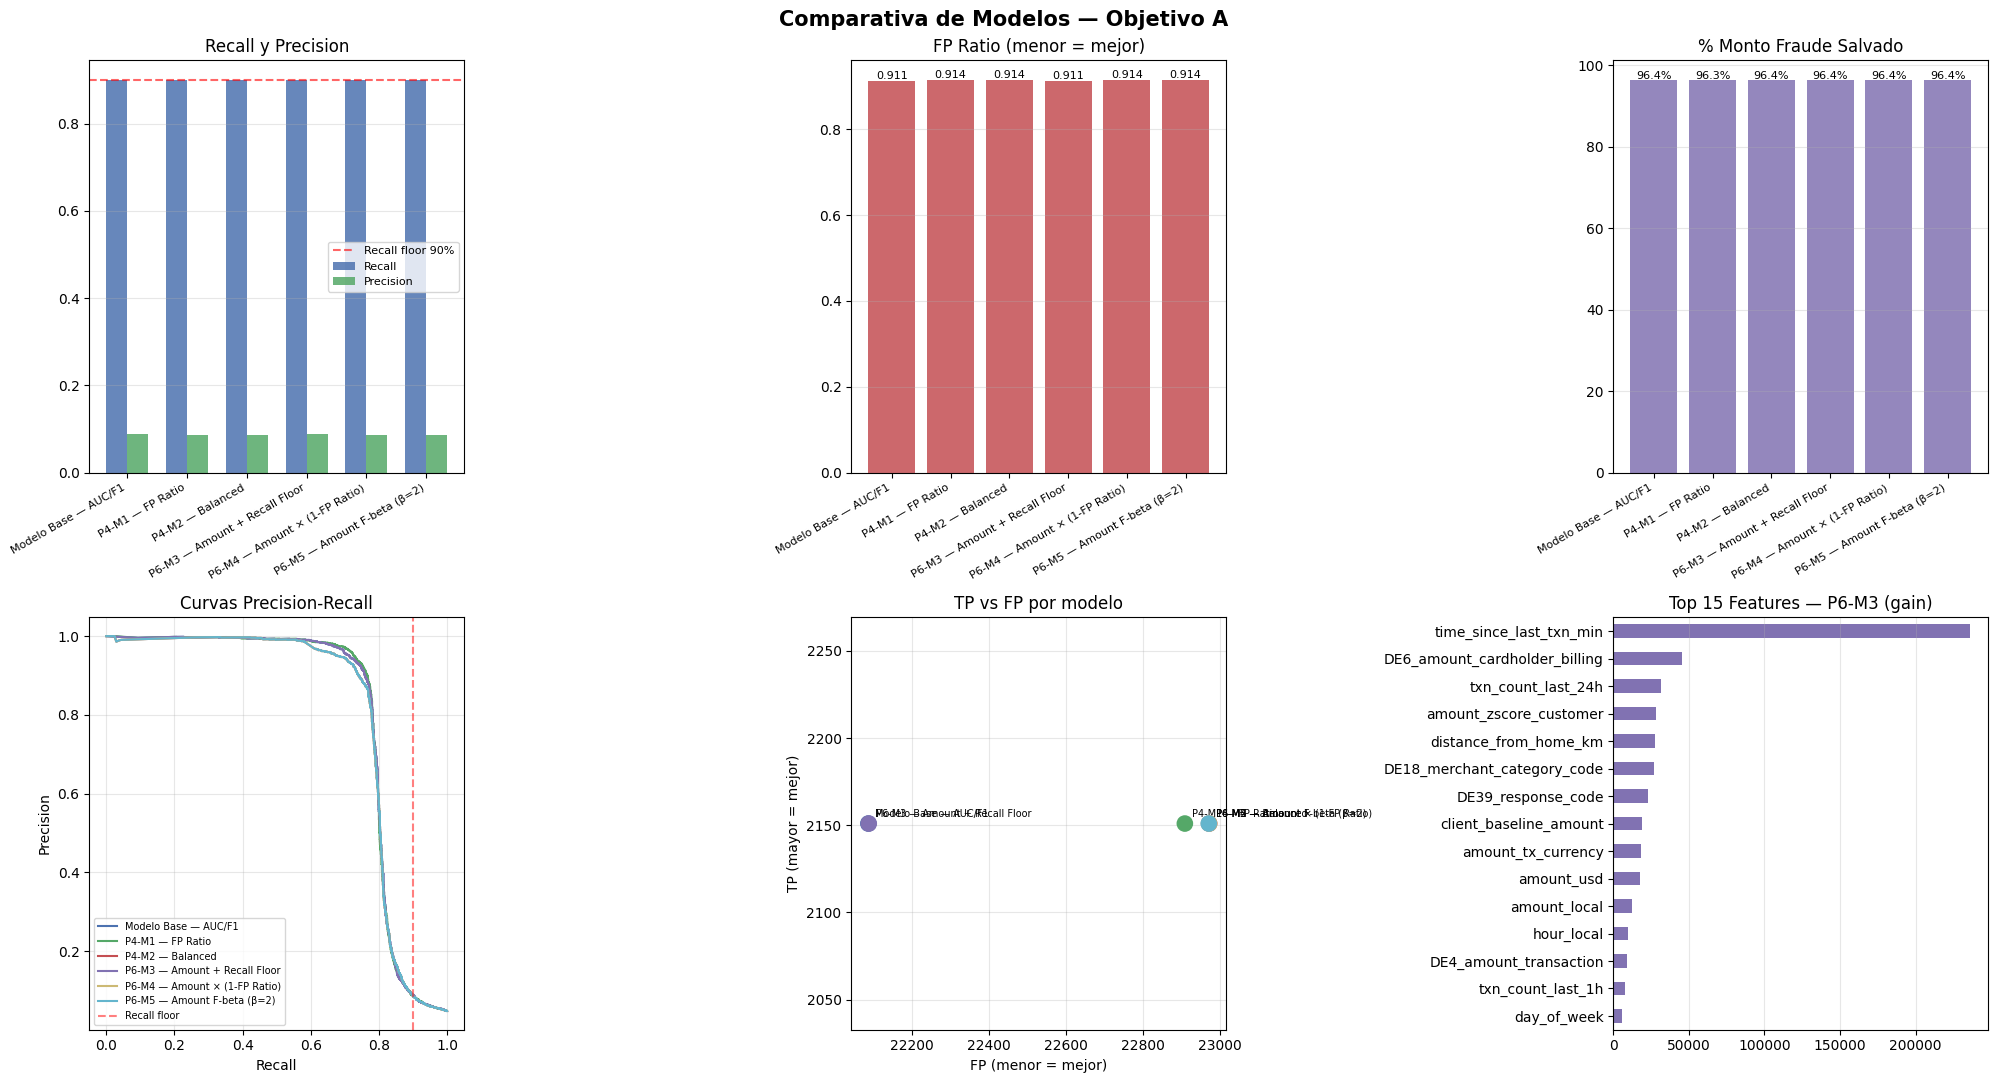

Figura guardada: /content/drive/MyDrive/proyecto_plus_ti/models/modelo_a/comparativa_objetivo_a.png


In [33]:
modelos     = df_comp.index.tolist()
colores     = ['#4C72B0','#55A868','#C44E52','#8172B2','#CCB974','#64B5CD']
x           = np.arange(len(modelos))

fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle('Comparativa de Modelos — Objetivo A', fontsize=15, fontweight='bold')

# Métricas clave
metrics_plot = ['Recall', 'Precision', 'FP Ratio', 'AUC-ROC']
for i, metric in enumerate(metrics_plot):
    ax = axes[i // 2, i % 2] if i < 4 else None

ax0 = axes[0, 0]
for j, m in enumerate(['Recall', 'Precision']):
    vals = df_comp[m].values
    ax0.bar(x + j*0.35 - 0.175, vals, 0.35, label=m, color=colores[j], alpha=0.85)
ax0.axhline(0.90, color='red', linestyle='--', alpha=0.6, label='Recall floor 90%')
ax0.set_xticks(x); ax0.set_xticklabels(modelos, rotation=30, ha='right', fontsize=8)
ax0.set_title('Recall y Precision'); ax0.legend(fontsize=8); ax0.grid(axis='y', alpha=0.3)

ax1 = axes[0, 1]
bars = ax1.bar(x, df_comp['FP Ratio'].values, color=colores[2], alpha=0.85)
ax1.set_xticks(x); ax1.set_xticklabels(modelos, rotation=30, ha='right', fontsize=8)
ax1.set_title('FP Ratio (menor = mejor)')
for bar, v in zip(bars, df_comp['FP Ratio'].values):
    ax1.text(bar.get_x()+bar.get_width()/2, v+0.005, f'{v:.3f}', ha='center', fontsize=8)
ax1.grid(axis='y', alpha=0.3)

ax2 = axes[0, 2]
bars = ax2.bar(x, df_comp['% Monto Salvado'].values, color=colores[3], alpha=0.85)
ax2.set_xticks(x); ax2.set_xticklabels(modelos, rotation=30, ha='right', fontsize=8)
ax2.set_title('% Monto Fraude Salvado')
for bar, v in zip(bars, df_comp['% Monto Salvado'].values):
    ax2.text(bar.get_x()+bar.get_width()/2, v+0.3, f'{v:.1f}%', ha='center', fontsize=8)
ax2.grid(axis='y', alpha=0.3)

# Curvas PR de todos los modelos
ax3 = axes[1, 0]
for prob, label, color in zip(
    [prob_base, prob_fp, prob_bal, prob_arf, prob_afw, prob_afb],
    modelos, colores
):
    prec, rec, _ = precision_recall_curve(y_test, prob)
    ax3.plot(rec, prec, label=label, color=color, linewidth=1.5)
ax3.axvline(0.90, color='red', linestyle='--', alpha=0.5, label='Recall floor')
ax3.set_xlabel('Recall'); ax3.set_ylabel('Precision')
ax3.set_title('Curvas Precision-Recall'); ax3.legend(fontsize=7); ax3.grid(alpha=0.3)

# TP vs FP
ax4 = axes[1, 1]
ax4.scatter(df_comp['FP'].values, df_comp['TP'].values,
            c=colores[:len(modelos)], s=120, zorder=5)
for i, label in enumerate(modelos):
    ax4.annotate(label, (df_comp['FP'].values[i], df_comp['TP'].values[i]),
                 textcoords='offset points', xytext=(5,5), fontsize=7)
ax4.set_xlabel('FP (menor = mejor)'); ax4.set_ylabel('TP (mayor = mejor)')
ax4.set_title('TP vs FP por modelo'); ax4.grid(alpha=0.3)

# Feature importance del mejor modelo del grupo (model_arf como referencia)
ax5 = axes[1, 2]
fi = pd.Series(
    model_arf.feature_importance(importance_type='gain'),
    index=FEATURES
).sort_values(ascending=True).tail(15)
fi.plot(kind='barh', ax=ax5, color=colores[3])
ax5.set_title('Top 15 Features — P6-M3 (gain)'); ax5.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PATH_OUTPUTS}/comparativa_objetivo_a.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Figura guardada: {PATH_OUTPUTS}/comparativa_objetivo_a.png')

## Conclusión y selección de función feval

In [34]:
# Filtrar modelos que cumplen recall >= 90%
candidatos = df_comp[df_comp['Recall'] >= 0.90].copy()

print('Modelos que cumplen recall >= 90%:')
print(candidatos[['Recall','FP Ratio','% Monto Salvado','FP']].to_string())

if len(candidatos) > 0:
    # Entre los que cumplen recall, el mejor en % monto salvado
    mejor_monto = candidatos['% Monto Salvado'].idxmax()
    # Entre los que cumplen recall, el mejor en FP ratio
    mejor_fp    = candidatos['FP Ratio'].idxmin()

    print(f'\n→ Mejor en % Monto Salvado : {mejor_monto}')
    print(f'→ Mejor en FP Ratio         : {mejor_fp}')

    print(f"""
CONCLUSIÓN:
El objetivo del grupo es maximizar el monto de fraude detectado
manteniendo recall >= 90% (piso mínimo operativo del banco).

Entre las 5 funciones evaluadas, la seleccionada es la que produce
el mayor '% Monto Salvado' entre los modelos que cumplen el piso:
  → {mejor_monto}

Justificación cuantitativa:
  % Monto Salvado : {candidatos.loc[mejor_monto, '% Monto Salvado']:.2f}%
  Recall          : {candidatos.loc[mejor_monto, 'Recall']:.2%}
  FP Ratio        : {candidatos.loc[mejor_monto, 'FP Ratio']:.4f}
  FP              : {int(candidatos.loc[mejor_monto, 'FP']):,}

Esta función guía al modelo a priorizar explícitamente el valor
económico de los fraudes detectados, no solo su cantidad, que es
lo que maximiza el impacto real para el banco.
""")
else:
    print('\n⚠ Ningún modelo alcanzó recall >= 90%. Revisar parámetros.')

Modelos que cumplen recall >= 90%:
                               Recall  FP Ratio  % Monto Salvado     FP
Modelo                                                                 
Modelo Base — AUC/F1           0.9004    0.9113            96.37  22088
P4-M1 — FP Ratio               0.9004    0.9142            96.29  22909
P4-M2 — Balanced               0.9004    0.9144            96.37  22972
P6-M3 — Amount + Recall Floor  0.9004    0.9113            96.37  22089
P6-M4 — Amount × (1-FP Ratio)  0.9004    0.9144            96.37  22972
P6-M5 — Amount F-beta (β=2)    0.9004    0.9144            96.37  22971

→ Mejor en % Monto Salvado : Modelo Base — AUC/F1
→ Mejor en FP Ratio         : Modelo Base — AUC/F1

CONCLUSIÓN:
El objetivo del grupo es maximizar el monto de fraude detectado
manteniendo recall >= 90% (piso mínimo operativo del banco).

Entre las 5 funciones evaluadas, la seleccionada es la que produce
el mayor '% Monto Salvado' entre los modelos que cumplen el piso:
  → Modelo Base